# Exercise 5: Generative-model comparison

This independently readable exercise notebook contains its objective, complete Python implementation, calculated output, interpretation, and limitation. The clean and executed editions are generated from the same canonical cells.

**Student:** S. M. Monowar Kayser (253-25-019)  
**Course:** Data Visualization (CSE628), Summer 2026

In [1]:
from pathlib import Path
import json
import sys
from IPython.display import HTML, Image, display
ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
if not (ROOT / 'pyproject.toml').exists():
    raise FileNotFoundError('Run this file inside the project checkout.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
SUMMARY = json.loads((ROOT / 'outputs' / 'analysis_summary.json').read_text(encoding='utf-8'))
print('Project root resolved successfully.')
print('Canonical summary loaded successfully.')

Project root resolved successfully.
Canonical summary loaded successfully.


## Exercise 5 - Generative-model statistics

**Objective.** Compare the exact seeded Erdos-Renyi, Watts-Strogatz, and Barabasi-Albert realizations using consistent structural metrics.

,Model,Nodes,Edges,Density,Average Degree,Average Clustering,Connected,Connected Components,Average Shortest Path,Path Length Scope,Maximum Degree,Degree Standard Deviation,Social-Network Similarity Notes
0,"Erdos-Renyi G(n,p)",30,33,0.075862,2.200000,0.072222,False,3,3.828042,largest connected component,4,1.166190,Homogeneous random mixing; limited clustering ...
1,Watts-Strogatz small-world,30,60,0.137931,4.000000,0.345556,True,1,2.983908,whole graph,5,0.632456,"High local clustering and short paths, but com..."
2,Barabasi-Albert scale-free,30,56,0.128736,3.733333,0.300196,True,1,2.181609,whole graph,18,3.520732,"Strong hubs and heterogeneous degrees, but wea..."


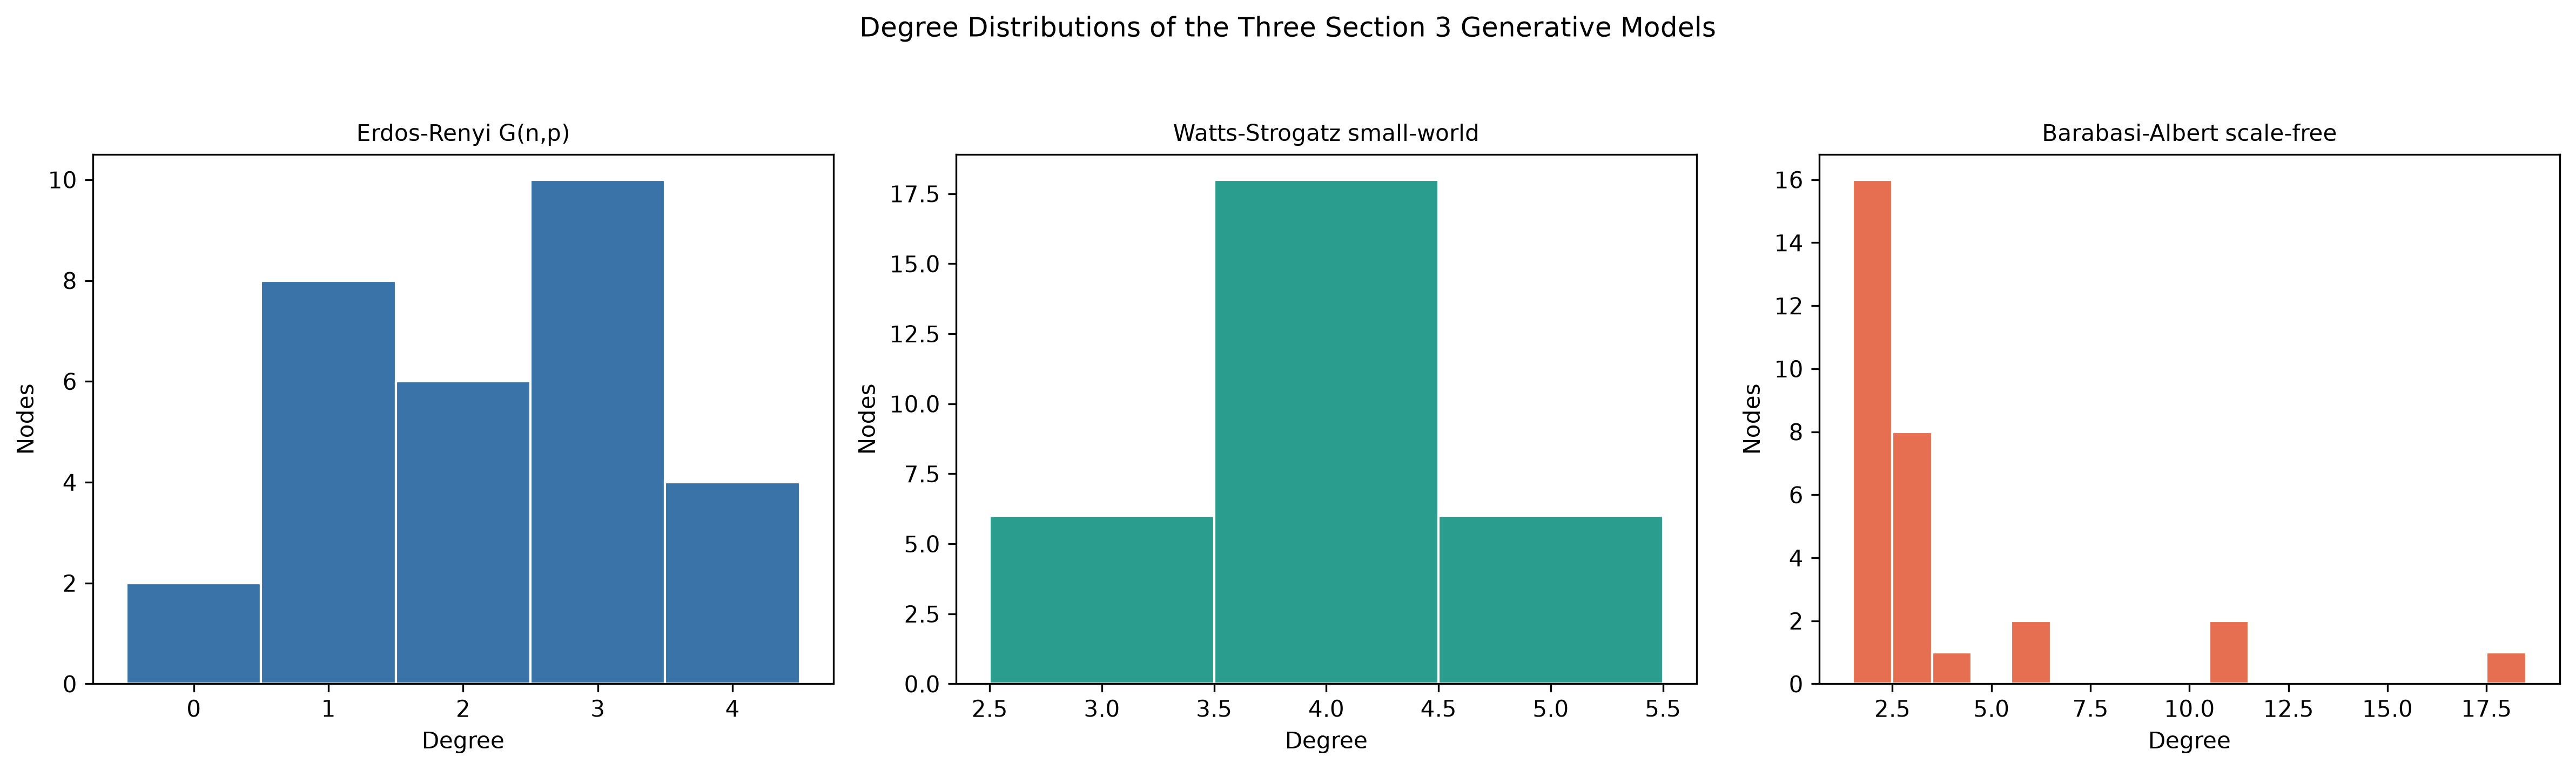

In [2]:
from src.graph_generators import build_generative_models
from src.network_analysis import compare_generative_models
model_table, distributions = compare_generative_models(build_generative_models())
display(model_table)
display(Image(filename=str(ROOT / 'visualizations' / 'static' / 'generative_models_degree_distribution.png'), alt='Degree distributions of three seeded generative graph models'))

**Interpretation.** Watts-Strogatz better represents clustering and short paths, whereas Barabasi-Albert better represents hubs and heterogeneous degree. Neither is universally closest to every social network.

**Limitation.** One small realization per model cannot characterize the full sampling distribution of the metrics.